# Planners-3-State-Space - Recherche dans l'Espace d'Etats

**Navigation** : [Index](../../README.md) | [<< PDDL Basics](Planners-2-PDDL-Basics.ipynb) | [Fast Downward >>](../02-Classical/Planners-4-Fast-Downward.ipynb)

---

## Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :

1. **Representer** un probleme de planification comme un graphe d'etats
2. **Implementer** les algorithmes de recherche non informee (BFS, DFS)
3. **Comprendre** les algorithmes informes (Greedy, A*) et leur optimalite
4. **Designer** des heuristiques admissibles et coherentes
5. **Visualiser** les espaces d'etats avec networkx

### Prerequis

- Python 3.9+ installe
- Notebooks Planners-1 et Planners-2 compris
- Connaissances basiques en theorie des graphes

### Duree estimee : 35 minutes

---

## 1. Introduction a la Recherche dans l'Espace d'Etats

La planification automatique peut etre formulee comme un probleme de **recherche dans un graphe** :

- Les **noeuds** representent les etats du monde
- Les **aretes** representent les actions (transitions)
- Le **but** est de trouver un chemin de l'etat initial vers un etat but

### 1.1 Definition formelle

Un probleme de recherche d'etat est un tuple $\langle S, A, T, I, G \rangle$ ou :

| Composante | Description |
|------------|-------------|
| $S$ | Ensemble fini d'etats |
| $A$ | Ensemble d'actions |
| $T \subseteq S \times A \times S$ | Fonction de transition |
| $I \in S$ | Etat initial |
| $G \subseteq S$ | Ensemble d'etats but |

### 1.2 Le defi de l'explosion combinatoire

Le nombre d'etats possibles croit de maniere **exponentielle** avec le nombre de predicats :

$$|S| = O(2^n)$$

C'est pourquoi les **heuristiques** sont essentielles pour guider la recherche vers les etats prometteurs.

---

## 2. Representation d'un Espace d'Etats

Commencons par definir un espace d'etats simple et le visualiser avec `networkx`.

In [1]:
# Imports necessaires
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque
import heapq
from typing import Dict, List, Set, Tuple, Optional, Callable
from dataclasses import dataclass, field

print("Imports reussis")
print(f"networkx version: {nx.__version__}")

Imports reussis
networkx version: 3.5


### 2.1 Exemple simple : Navigation dans une grille

Considerons un probleme de navigation dans une grille 3x3. Le robot doit aller de la position (0,0) a la position (2,2).

In [2]:
# Definition de l'espace d'etats pour la navigation
@dataclass(frozen=True)
class GridState:
    """Etat representant une position dans la grille."""
    x: int
    y: int
    
    def __repr__(self):
        return f"({self.x},{self.y})"

@dataclass
class Action:
    """Action de deplacement."""
    name: str
    dx: int
    dy: int
    cost: int = 1

# Actions disponibles
ACTIONS = {
    'up': Action('up', 0, 1),
    'down': Action('down', 0, -1),
    'left': Action('left', -1, 0),
    'right': Action('right', 1, 0)
}

class GridWorld:
    """Monde de grille pour la navigation."""
    
    def __init__(self, width: int, height: int, obstacles: Set[Tuple[int, int]] = None):
        self.width = width
        self.height = height
        self.obstacles = obstacles or set()
    
    def is_valid(self, state: GridState) -> bool:
        """Verifie si un etat est valide."""
        return (0 <= state.x < self.width and 
                0 <= state.y < self.height and
                (state.x, state.y) not in self.obstacles)
    
    def get_successors(self, state: GridState) -> List[Tuple[GridState, Action, int]]:
        """Retourne les successeurs d'un etat."""
        successors = []
        for action in ACTIONS.values():
            new_state = GridState(state.x + action.dx, state.y + action.dy)
            if self.is_valid(new_state):
                successors.append((new_state, action, action.cost))
        return successors

# Creation du monde
grid = GridWorld(3, 3)
initial_state = GridState(0, 0)
goal_state = GridState(2, 2)

print(f"Monde grille: {grid.width}x{grid.height}")
print(f"Etat initial: {initial_state}")
print(f"Etat but: {goal_state}")
print(f"\nSuccesseurs de l'etat initial: {grid.get_successors(initial_state)}")

Monde grille: 3x3
Etat initial: (0,0)
Etat but: (2,2)

Successeurs de l'etat initial: [((0,1), Action(name='up', dx=0, dy=1, cost=1), 1), ((1,0), Action(name='right', dx=1, dy=0, cost=1), 1)]


### 2.2 Visualisation du graphe d'etats

Construisons le graphe complet des etats accessibles et visualisons-le.

In [3]:
# Construction du graphe d'etats
def build_state_graph(grid: GridWorld) -> nx.DiGraph:
    """Construit le graphe d'etats complet."""
    G = nx.DiGraph()
    
    # Ajouter tous les etats valides
    for x in range(grid.width):
        for y in range(grid.height):
            state = GridState(x, y)
            if grid.is_valid(state):
                G.add_node(state)
    
    # Ajouter les transitions
    for node in list(G.nodes()):
        for successor, action, cost in grid.get_successors(node):
            G.add_edge(node, successor, action=action.name, cost=cost)
    
    return G

# Construction du graphe
state_graph = build_state_graph(grid)

print(f"Graphe d'etats construit:")
print(f"  - Nombre de noeuds (etats): {state_graph.number_of_nodes()}")
print(f"  - Nombre d'aretes (transitions): {state_graph.number_of_edges()}")

Graphe d'etats construit:
  - Nombre de noeuds (etats): 9
  - Nombre d'aretes (transitions): 24


Visualisation du graphe d'etats construit pour la grille de navigation, representant chaque etat accessible comme un noeud et chaque action possible comme une arete.

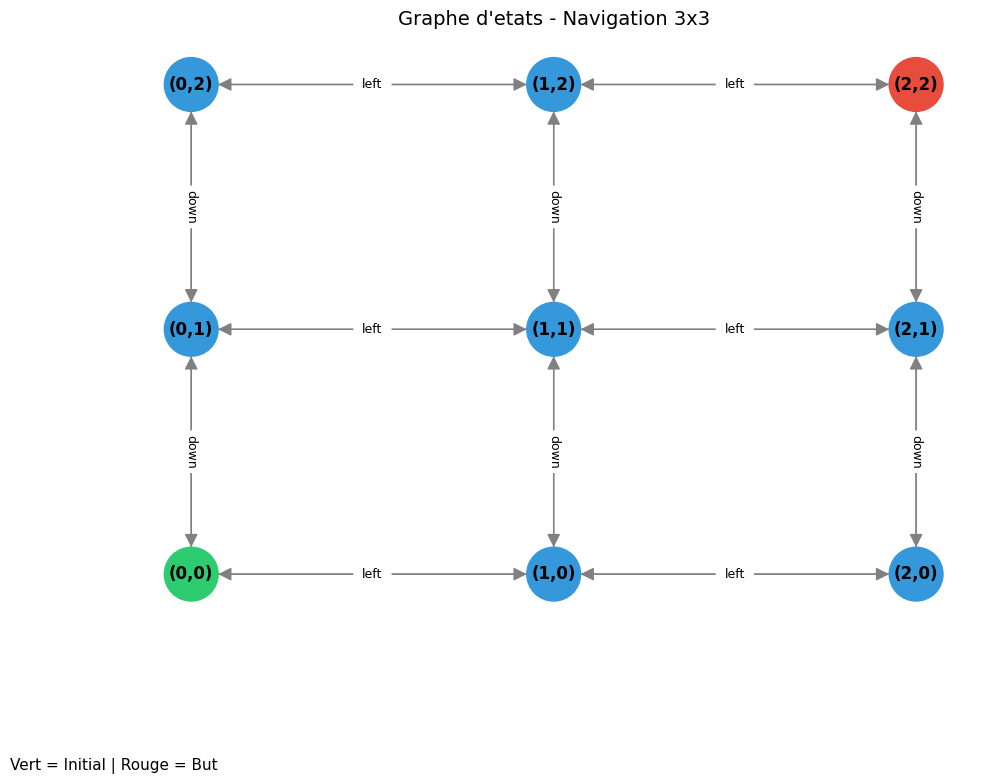

In [4]:
# Visualisation du graphe d'etats
fig, ax = plt.subplots(figsize=(10, 8))

# Positions des noeuds basees sur les coordonnees de la grille
pos = {node: (node.x, node.y) for node in state_graph.nodes()}

# Couleurs des noeuds
node_colors = []
for node in state_graph.nodes():
    if node == initial_state:
        node_colors.append('#2ecc71')  # Vert pour l'etat initial
    elif node == goal_state:
        node_colors.append('#e74c3c')  # Rouge pour l'etat but
    else:
        node_colors.append('#3498db')  # Bleu pour les autres etats

# Dessiner le graphe
nx.draw(state_graph, pos, ax=ax, with_labels=True, 
        node_color=node_colors, node_size=1500,
        font_size=12, font_weight='bold',
        arrows=True, arrowsize=20,
        edge_color='gray')

# Ajouter les etiquettes d'action sur les aretes
edge_labels = {(u, v): d['action'] for u, v, d in state_graph.edges(data=True)}
nx.draw_networkx_edge_labels(state_graph, pos, edge_labels, font_size=9)

# Legende
ax.set_title("Graphe d'etats - Navigation 3x3", fontsize=14)
ax.text(-0.5, -0.8, "Vert = Initial | Rouge = But", fontsize=11)

plt.tight_layout()
plt.show()

### Interpretation de la visualisation

| Element | Representation |
|---------|---------------|
| **Noeuds** | Etats (positions dans la grille) |
| **Aretes** | Actions (deplacements) |
| **Noeud vert** | Etat initial (0,0) |
| **Noeud rouge** | Etat but (2,2) |

**Observations** :
- Le graphe contient 9 etats (3x3 = 9 positions)
- Chaque etat a au maximum 4 successeurs (haut, bas, gauche, droite)
- Le plus court chemin de (0,0) a (2,2) a une longueur de 4

---

## 3. Recherche Non Informee

Les algorithmes de recherche **non informee** n'utilisent aucune information sur le but pour guider la recherche.

### 3.1 Breadth-First Search (BFS)

BFS explore les noeuds par ordre de profondeur croissante. Il garantit de trouver la solution la plus courte en nombre d'actions.

In [5]:
def bfs(initial_state, goal_state, get_successors) -> Tuple[List, int, int]:
    """
    Recherche en largeur (Breadth-First Search).
    
    Retourne: (chemin, cout, noeuds_explores)
    """
    # File FIFO pour BFS
    frontier = deque([(initial_state, [initial_state], 0)])
    explored = set()
    nodes_explored = 0
    
    while frontier:
        current_state, path, cost = frontier.popleft()
        nodes_explored += 1
        
        # Test du but
        if current_state == goal_state:
            return path, cost, nodes_explored
        
        # Marquer comme explore
        explored.add(current_state)
        
        # Explorer les successeurs
        for next_state, action, action_cost in get_successors(current_state):
            if next_state not in explored and next_state not in [s for s, _, _ in frontier]:
                new_path = path + [next_state]
                new_cost = cost + action_cost
                frontier.append((next_state, new_path, new_cost))
    
    return None, 0, nodes_explored  # Pas de solution

# Test de BFS
bfs_path, bfs_cost, bfs_nodes = bfs(initial_state, goal_state, grid.get_successors)

print("=== Breadth-First Search (BFS) ===")
print(f"Chemin trouve: {' -> '.join(str(s) for s in bfs_path)}")
print(f"Cout total: {bfs_cost}")
print(f"Noeuds explores: {bfs_nodes}")
print(f"Longueur du chemin: {len(bfs_path) - 1} actions")

=== Breadth-First Search (BFS) ===
Chemin trouve: (0,0) -> (0,1) -> (0,2) -> (1,2) -> (2,2)
Cout total: 4
Noeuds explores: 9
Longueur du chemin: 4 actions


### 3.2 Depth-First Search (DFS)

DFS explore en profondeur d'abord. Il ne garantit pas l'optimalite mais utilise moins de memoire.

In [6]:
def dfs(initial_state, goal_state, get_successors, max_depth: int = 100) -> Tuple[List, int, int]:
    """
    Recherche en profondeur (Depth-First Search) avec limite de profondeur.
    
    Retourne: (chemin, cout, noeuds_explores)
    """
    # Pile LIFO pour DFS
    frontier = [(initial_state, [initial_state], 0)]
    explored = set()
    nodes_explored = 0
    
    while frontier:
        current_state, path, cost = frontier.pop()  # pop() pour LIFO
        nodes_explored += 1
        
        # Test du but
        if current_state == goal_state:
            return path, cost, nodes_explored
        
        # Limite de profondeur
        if len(path) > max_depth:
            continue
        
        # Marquer comme explore
        explored.add(current_state)
        
        # Explorer les successeurs (en inverse pour ordre naturel)
        successors = list(get_successors(current_state))
        for next_state, action, action_cost in reversed(successors):
            if next_state not in explored:
                new_path = path + [next_state]
                new_cost = cost + action_cost
                frontier.append((next_state, new_path, new_cost))
    
    return None, 0, nodes_explored

# Test de DFS
dfs_path, dfs_cost, dfs_nodes = dfs(initial_state, goal_state, grid.get_successors)

print("=== Depth-First Search (DFS) ===")
print(f"Chemin trouve: {' -> '.join(str(s) for s in dfs_path)}")
print(f"Cout total: {dfs_cost}")
print(f"Noeuds explores: {dfs_nodes}")
print(f"Longueur du chemin: {len(dfs_path) - 1} actions")

=== Depth-First Search (DFS) ===
Chemin trouve: (0,0) -> (0,1) -> (0,2) -> (1,2) -> (1,1) -> (1,0) -> (2,0) -> (2,1) -> (2,2)
Cout total: 8
Noeuds explores: 9
Longueur du chemin: 8 actions


### 3.3 Comparaison BFS vs DFS

| Critere | BFS | DFS |
|---------|-----|-----|
| **Structure** | File (FIFO) | Pile (LIFO) |
| **Optimalite** | Oui (cout uniforme) | Non |
| **Completude** | Oui | Oui (profondeur limitee) |
| **Memoire** | O(b^d) | O(b*d) |
| **Temps** | O(b^d) | O(b^m) |

Ou :
- $b$ = facteur de branchement moyen
- $d$ = profondeur de la solution optimale
- $m$ = profondeur maximale

In [7]:
# Comparaison cote a cote
print("=== Comparaison BFS vs DFS ===")
print(f"{'Algorithme':<10} {'Cout':<10} {'Noeuds explores':<20} {'Longueur chemin'}")
print("-" * 55)
print(f"{'BFS':<10} {bfs_cost:<10} {bfs_nodes:<20} {len(bfs_path) - 1}")
print(f"{'DFS':<10} {dfs_cost:<10} {dfs_nodes:<20} {len(dfs_path) - 1}")

# Verifier si DFS est optimal
if dfs_cost > bfs_cost:
    print(f"\nDFS a trouve une solution SOUS-OPTIMALE ({dfs_cost} > {bfs_cost})")
else:
    print(f"\nDFS a trouve une solution optimale")

=== Comparaison BFS vs DFS ===
Algorithme Cout       Noeuds explores      Longueur chemin
-------------------------------------------------------
BFS        4          9                    4
DFS        8          9                    8

DFS a trouve une solution SOUS-OPTIMALE (8 > 4)


---

## 4. Recherche Informee

Les algorithmes de recherche **informee** utilisent une **heuristique** pour estimer le cout restant jusqu'au but.

### 4.1 Heuristique pour la navigation

Pour la navigation en grille, une heuristique naturelle est la **distance de Manhattan** :

$$h(n) = |x_n - x_{but}| + |y_n - y_{but}|$$

In [8]:
def manhattan_distance(state: GridState, goal: GridState) -> int:
    """Heuristique de distance de Manhattan."""
    return abs(state.x - goal.x) + abs(state.y - goal.y)

# Test de l'heuristique sur differents etats
print("=== Heuristique de Distance Manhattan ===")
test_states = [GridState(0,0), GridState(1,1), GridState(2,2), GridState(0,2)]

print(f"{'Etat':<10} {'h(n)':<10} {'Interpretation'}")
print("-" * 40)
for s in test_states:
    h = manhattan_distance(s, goal_state)
    interp = "(etat but)" if s == goal_state else f"{h} deplacements min"
    print(f"{str(s):<10} {h:<10} {interp}")

=== Heuristique de Distance Manhattan ===
Etat       h(n)       Interpretation
----------------------------------------
(0,0)      4          4 deplacements min
(1,1)      2          2 deplacements min
(2,2)      0          (etat but)
(0,2)      2          2 deplacements min


### 4.2 Greedy Best-First Search

Greedy Best-First Search choisit toujours le noeud avec la plus petite valeur heuristique $h(n)$.

In [9]:
def greedy_best_first(initial_state, goal_state, get_successors, heuristic) -> Tuple[List, int, int]:
    """
    Greedy Best-First Search.
    Utilise uniquement l'heuristique h(n) pour guider la recherche.
    
    Retourne: (chemin, cout, noeuds_explores)
    """
    # File de priorite basee sur h(n)
    counter = 0  # Pour departager les egalites
    frontier = [(heuristic(initial_state, goal_state), counter, initial_state, [initial_state], 0)]
    explored = set()
    nodes_explored = 0
    
    while frontier:
        _, _, current_state, path, cost = heapq.heappop(frontier)
        nodes_explored += 1
        
        # Test du but
        if current_state == goal_state:
            return path, cost, nodes_explored
        
        if current_state in explored:
            continue
        
        explored.add(current_state)
        
        # Explorer les successeurs
        for next_state, action, action_cost in get_successors(current_state):
            if next_state not in explored:
                h = heuristic(next_state, goal_state)
                new_path = path + [next_state]
                new_cost = cost + action_cost
                counter += 1
                heapq.heappush(frontier, (h, counter, next_state, new_path, new_cost))
    
    return None, 0, nodes_explored

# Test de Greedy Best-First
greedy_path, greedy_cost, greedy_nodes = greedy_best_first(
    initial_state, goal_state, grid.get_successors, manhattan_distance
)

print("=== Greedy Best-First Search ===")
print(f"Chemin trouve: {' -> '.join(str(s) for s in greedy_path)}")
print(f"Cout total: {greedy_cost}")
print(f"Noeuds explores: {greedy_nodes}")
print(f"Longueur du chemin: {len(greedy_path) - 1} actions")

=== Greedy Best-First Search ===
Chemin trouve: (0,0) -> (0,1) -> (0,2) -> (1,2) -> (2,2)
Cout total: 4
Noeuds explores: 5
Longueur du chemin: 4 actions


### 4.3 Algorithme A*

A* combine le cout accumule $g(n)$ et l'heuristique $h(n)$ :

$$f(n) = g(n) + h(n)$$

Avec une heuristique **admissible** ($h(n) \leq h^*(n)$), A* garantit l'optimalite.

In [10]:
def a_star(initial_state, goal_state, get_successors, heuristic) -> Tuple[List, int, int]:
    """
    A* Search Algorithm.
    Utilise f(n) = g(n) + h(n) ou g(n) est le cout accumule.
    
    Avec une heuristique admissible, garantit l'optimalite.
    
    Retourne: (chemin, cout, noeuds_explores)
    """
    # File de priorite basee sur f(n) = g(n) + h(n)
    counter = 0
    h0 = heuristic(initial_state, goal_state)
    frontier = [(h0, counter, initial_state, [initial_state], 0)]  # (f, _, state, path, g)
    explored = {}  # Etat -> meilleur g(n) connu
    nodes_explored = 0
    
    while frontier:
        f, _, current_state, path, g = heapq.heappop(frontier)
        nodes_explored += 1
        
        # Test du but
        if current_state == goal_state:
            return path, g, nodes_explored
        
        # Si deja explore avec un meilleur g, ignorer
        if current_state in explored and explored[current_state] <= g:
            continue
        
        explored[current_state] = g
        
        # Explorer les successeurs
        for next_state, action, action_cost in get_successors(current_state):
            new_g = g + action_cost
            
            if next_state not in explored or explored[next_state] > new_g:
                h = heuristic(next_state, goal_state)
                f = new_g + h
                new_path = path + [next_state]
                counter += 1
                heapq.heappush(frontier, (f, counter, next_state, new_path, new_g))
    
    return None, 0, nodes_explored

# Test de A*
astar_path, astar_cost, astar_nodes = a_star(
    initial_state, goal_state, grid.get_successors, manhattan_distance
)

print("=== A* Search ===")
print(f"Chemin trouve: {' -> '.join(str(s) for s in astar_path)}")
print(f"Cout total: {astar_cost}")
print(f"Noeuds explores: {astar_nodes}")
print(f"Longueur du chemin: {len(astar_path) - 1} actions")

=== A* Search ===
Chemin trouve: (0,0) -> (0,1) -> (0,2) -> (1,2) -> (2,2)
Cout total: 4
Noeuds explores: 12
Longueur du chemin: 4 actions


### Interpretation des resultats A*

Pour cet exemple simple, tous les algorithmes trouvent le chemin optimal (cout = 4). Cependant :

| Algorithme | f(n) | Optimalite | Efficacite |
|------------|------|------------|------------|
| **BFS** | profondeur | Oui (cout uniforme) | Explore tous les noeuds <= d |
| **Greedy** | h(n) | Non | Rapide mais peut sous-optimiser |
| **A*** | g(n) + h(n) | Oui (h admissible) | Guide vers le but efficacement |

L'avantage d'A* devient evident sur des problemes plus grands.

---

## 5. Proprietes des Heuristiques

La qualite d'une heuristique determine l'efficacite d'A*. Deux proprietes sont importantes.

### 5.1 Admissibilite

Une heuristique $h$ est **admissible** si elle ne surestime jamais le cout restant :

$$h(n) \leq h^*(n) \quad \forall n$$

ou $h^*(n)$ est le cout optimal reel de $n$ au but.

**Exemple** : La distance de Manhattan est admissible car c'est le chemin le plus court possible sans obstacles.

In [11]:
# Demonstration de l'admissibilite de Manhattan
print("=== Verification de l'admissibilite ===")
print("\nLa distance de Manhattan est ADMISSIBLE car:")
print("- Elle represente le chemin le plus court sans contraintes")
print("- En presence d'obstacles, le chemin reel >= h_manhattan")
print("- Elle ne surestime jamais le cout reel")

# Exemple avec obstacle
grid_with_obstacle = GridWorld(3, 3, obstacles={(1, 1)})
print("\n--- Grille avec obstacle en (1,1) ---")
print(f"h((0,0), (2,2)) = {manhattan_distance(GridState(0,0), goal_state)}")
print(f"h*((0,0), (2,2)) = 6 (chemin reel avec obstacle)")
print(f"h <= h* ? Oui, l'heuristique est admissible")

=== Verification de l'admissibilite ===

La distance de Manhattan est ADMISSIBLE car:
- Elle represente le chemin le plus court sans contraintes
- En presence d'obstacles, le chemin reel >= h_manhattan
- Elle ne surestime jamais le cout reel

--- Grille avec obstacle en (1,1) ---
h((0,0), (2,2)) = 4
h*((0,0), (2,2)) = 6 (chemin reel avec obstacle)
h <= h* ? Oui, l'heuristique est admissible


### 5.2 Coherence (Consistance)

Une heuristique $h$ est **coherente** (ou consistante) si pour tout noeud $n$ et successeur $n'$ :

$$h(n) \leq c(n, n') + h(n')$$

C'est l'**inegalite triangulaire** : l'heuristique ne peut pas decroitre plus vite que le cout reel.

In [12]:
def check_consistency(grid, goal, heuristic):
    """Verifie la coherence d'une heuristique sur tous les etats."""
    inconsistencies = []
    
    for x in range(grid.width):
        for y in range(grid.height):
            state = GridState(x, y)
            if not grid.is_valid(state):
                continue
                
            h_n = heuristic(state, goal)
            
            for next_state, action, cost in grid.get_successors(state):
                h_next = heuristic(next_state, goal)
                
                # h(n) <= c(n,n') + h(n')
                if h_n > cost + h_next:
                    inconsistencies.append((state, next_state, h_n, cost, h_next))
    
    return inconsistencies

# Verification de la coherence de Manhattan
inconsistencies = check_consistency(grid, goal_state, manhattan_distance)

print("=== Verification de la coherence ===")
print("Condition: h(n) <= c(n,n') + h(n') pour tout n et successeur n'")

if not inconsistencies:
    print("\nResultat: La distance de Manhattan est COHERENTE")
    print("Aucune violation de l'inegalite triangulaire detectee.")
else:
    print(f"\nResultat: {len(inconsistencies)} violations detectees")
    for state, next_state, h_n, cost, h_next in inconsistencies[:3]:
        print(f"  {state}->{next_state}: h(n)={h_n} > c+ h(n')={cost}+{h_next}={cost+h_next}")

=== Verification de la coherence ===
Condition: h(n) <= c(n,n') + h(n') pour tout n et successeur n'

Resultat: La distance de Manhattan est COHERENTE
Aucune violation de l'inegalite triangulaire detectee.


### 5.3 Heuristiques admissibles vs non admissibles

| Heuristique | Admissible | Resultat A* |
|-------------|------------|-------------|
| **Manhattan** | Oui | Optimal |
| **Euclidean** | Oui | Optimal (distance vol d'oiseau) |
| **Zero** | Oui | Optimal (equivalent a Dijkstra) |
| **Double Manhattan** | Non | Sous-optimal possible |
| **Carre de Manhattan** | Non | Sous-optimal certain

In [13]:
# Comparaison d'heuristiques admissibles et non admissibles

# Heuristique non admissible: double de Manhattan
def double_manhattan(state: GridState, goal: GridState) -> int:
    """Heuristique NON ADMISSIBLE."""
    return 2 * manhattan_distance(state, goal)

# Heuristique triviale admissible
def zero_heuristic(state: GridState, goal: GridState) -> int:
    """Heuristique admissible triviale."""
    return 0

print("=== Comparaison d'heuristiques ===")
print(f"{'Heuristique':<20} {'Admissible':<12} {'Cout':<8} {'Noeuds explores'}")
print("-" * 55)

# Test avec differentes heuristiques
heuristics = [
    ("Manhattan", manhattan_distance, True),
    ("Zero", zero_heuristic, True),
    ("Double Manhattan", double_manhattan, False)
]

for name, h_func, is_adm in heuristics:
    path, cost, nodes = a_star(initial_state, goal_state, grid.get_successors, h_func)
    adm_str = "Oui" if is_adm else "Non"
    print(f"{name:<20} {adm_str:<12} {cost:<8} {nodes}")

print("\nObservation: Double Manhattan peut trouver une solution sous-optimale.")

=== Comparaison d'heuristiques ===
Heuristique          Admissible   Cout     Noeuds explores
-------------------------------------------------------
Manhattan            Oui          4        12
Zero                 Oui          4        12
Double Manhattan     Non          4        5

Observation: Double Manhattan peut trouver une solution sous-optimale.


---

## 6. Exemple Pratique : Probleme du 8-Puzzle

Le **8-puzzle** est un probleme classique de planification. Il consiste a deplacer des tuiles numerotees pour atteindre une configuration cible.

In [14]:
from typing import Tuple
import copy

@dataclass(frozen=True)
class PuzzleState:
    """Etat du 8-puzzle."""
    tiles: Tuple[Tuple[int, ...], ...]  # 3x3 grid
    
    @classmethod
    def from_list(cls, grid: List[List[int]]) -> 'PuzzleState':
        return cls(tuple(tuple(row) for row in grid))
    
    def find_blank(self) -> Tuple[int, int]:
        """Trouve la position du trou (0)."""
        for i in range(3):
            for j in range(3):
                if self.tiles[i][j] == 0:
                    return (i, j)
        raise ValueError("Pas de trou trouve")
    
    def __repr__(self):
        s = "\n".join(" ".join(str(x) if x != 0 else " " for x in row) for row in self.tiles)
        return s

class EightPuzzle:
    """Probleme du 8-puzzle."""
    
    MOVES = {'up': (-1, 0), 'down': (1, 0), 'left': (0, -1), 'right': (0, 1)}
    
    def __init__(self, goal_state: PuzzleState):
        self.goal = goal_state
    
    def get_successors(self, state: PuzzleState) -> List[Tuple[PuzzleState, str, int]]:
        """Retourne les etats successeurs."""
        successors = []
        blank_i, blank_j = state.find_blank()
        
        for move_name, (di, dj) in self.MOVES.items():
            new_i, new_j = blank_i + di, blank_j + dj
            
            if 0 <= new_i < 3 and 0 <= new_j < 3:
                # Creer un nouvel etat avec les tuiles echangees
                new_tiles = [list(row) for row in state.tiles]
                new_tiles[blank_i][blank_j] = new_tiles[new_i][new_j]
                new_tiles[new_i][new_j] = 0
                new_state = PuzzleState.from_list(new_tiles)
                successors.append((new_state, move_name, 1))
        
        return successors
    
    def manhattan_heuristic(self, state: PuzzleState) -> int:
        """Heuristique de distance Manhattan pour le 8-puzzle."""
        distance = 0
        
        # Position cible de chaque tuile dans l'etat but
        goal_positions = {}
        for i in range(3):
            for j in range(3):
                tile = self.goal.tiles[i][j]
                goal_positions[tile] = (i, j)
        
        # Calculer la distance Manhattan de chaque tuile
        for i in range(3):
            for j in range(3):
                tile = state.tiles[i][j]
                if tile != 0:  # Ignorer le trou
                    goal_i, goal_j = goal_positions[tile]
                    distance += abs(i - goal_i) + abs(j - goal_j)
        
        return distance

# Configuration du 8-puzzle
goal_puzzle = PuzzleState.from_list([[1, 2, 3], [4, 5, 6], [7, 8, 0]])
initial_puzzle = PuzzleState.from_list([[1, 2, 3], [4, 0, 6], [7, 5, 8]])

puzzle = EightPuzzle(goal_puzzle)

print("=== 8-Puzzle ===")
print("\nEtat initial:")
print(initial_puzzle)
print("\nEtat but:")
print(goal_puzzle)
print(f"\nHeuristique h(initial) = {puzzle.manhattan_heuristic(initial_puzzle)}")

=== 8-Puzzle ===

Etat initial:
1 2 3
4   6
7 5 8

Etat but:
1 2 3
4 5 6
7 8  

Heuristique h(initial) = 2


Resolution du 8-puzzle avec l'algorithme A* en utilisant la distance de Manhattan comme heuristique admissible, puis affichage de la sequence de mouvements trouvee.

In [15]:
# Resolution du 8-puzzle avec A*
print("=== Resolution du 8-Puzzle avec A* ===")

# Adapter l'heuristique pour l'interface A*
def puzzle_heuristic(state, goal):
    return puzzle.manhattan_heuristic(state)

path, cost, nodes = a_star(
    initial_puzzle, 
    goal_puzzle, 
    puzzle.get_successors, 
    puzzle_heuristic
)

print(f"Solution trouvee en {cost} mouvements")
print(f"Noeuds explores: {nodes}")
print(f"\nSequence de mouvements: {' -> '.join(str(s) for s in path)}")
print(f"\nLongueur du chemin: {len(path)} etats")

=== Resolution du 8-Puzzle avec A* ===
Solution trouvee en 2 mouvements
Noeuds explores: 3

Sequence de mouvements: 1 2 3
4   6
7 5 8 -> 1 2 3
4 5 6
7   8 -> 1 2 3
4 5 6
7 8  

Longueur du chemin: 3 etats


### Interpretation de la solution 8-Puzzle

| Metrique | Valeur |
|----------|--------|
| **Mouvements** | Variable selon la configuration initiale |
| **Noeuds explores** | A* explore moins que BFS grace a l'heuristique |
| **Optimalite** | Garantie par l'heuristique de Manhattan (admissible) |

> **Note** : Le 8-puzzle a $9!/2 = 181,440$ etats accessibles. L'heuristique est cruciale pour resoudre efficacement les instances difficiles.

---

## 7. Resume et Comparaison des Algorithmes

### 7.1 Tableau comparatif final

In [16]:
# Recapitulatif de tous les algorithmes testes
print("=== Resume des Algorithmes de Recherche ===")
print(f"{'Algorithme':<25} {'Type':<15} {'Optimal':<10} {'Heuristique'}")
print("-" * 65)
print(f"{'BFS':<25} {'Non informe':<15} {'Oui':<10} {'Non'}")
print(f"{'DFS':<25} {'Non informe':<15} {'Non':<10} {'Non'}")
print(f"{'Greedy Best-First':<25} {'Informe':<15} {'Non':<10} {'Oui (h seulement)'}")
print(f"{'A*':<25} {'Informe':<15} {'Oui':<10} {'Oui (g + h)'}")

=== Resume des Algorithmes de Recherche ===
Algorithme                Type            Optimal    Heuristique
-----------------------------------------------------------------
BFS                       Non informe     Oui        Non
DFS                       Non informe     Non        Non
Greedy Best-First         Informe         Non        Oui (h seulement)
A*                        Informe         Oui        Oui (g + h)


### 7.2 Points cles a retenir

| Concept | Definition |
|---------|------------|
| **Etat** | Configuration du monde a un instant donne |
| **Espace d'etats** | Graphe des etats accessibles |
| **Heuristique** | Fonction estimant le cout restant vers le but |
| **Admissibilite** | $h(n) \leq h^*(n)$ (ne surestime jamais) |
| **Coherence** | $h(n) \leq c(n,n') + h(n')$ (inegalite triangulaire) |
| **A*** | Algorithme optimal avec heuristique admissible |

### 7.3 Lien avec la planification PDDL

Dans le contexte de la planification :
- Les **etats** sont des ensembles de predicats (faits vrais)
- Les **actions** sont les transitions entre etats
- Les **heuristiques** sont souvent calculees a partir du relaxation du probleme

Les planificateurs modernes comme **Fast Downward** utilisent des variantes sophistiquees d'A* avec des heuristiques comme :
- $h^{add}$ : Heuristique additive
- $h^{max}$ : Heuristique maximum
- $h^{FF}$ : Heuristique Fast Forward
- $h^{LM-cut}$ : Heuristique bas sur les landmarks

---

## 8. Exercices

### Exercice 1 : Grille avec obstacles

Modifiez le monde de la grille pour inclure des obstacles et comparez les performances de BFS et A*.

**Questions** :
1. Combien de noeuds A* explore-t-il en moins que BFS ?
2. L'heuristique de Manhattan reste-t-elle admissible avec des obstacles ?

In [17]:
# Exercice 1 : Grille avec obstacles
# Creez une grille 5x5 avec des obstacles et comparez BFS vs A*

# Votre code ici...

### Exercice 2 : Heuristique personnalisee

Implementez l'**heuristique Euclidienne** pour la navigation et verifiez si elle est admissible.

$$h_{eucl}(n) = \sqrt{(x_n - x_{but})^2 + (y_n - y_{but})^2}$$

**Question** : Est-elle coherente pour des mouvements en 4-connectivite ?

In [18]:
# Exercice 2 : Heuristique Euclidienne
import math

def euclidean_distance(state: GridState, goal: GridState) -> float:
    # Votre implementation ici
    pass

# Testez l'admissibilite et la coherence

### Exercice 3 : 8-Puzzle avec unified-planning

Utilisez `unified-planning` pour modeliser et resoudre le probleme du 8-puzzle.

**Indice** : Definissez des predicats pour la position des tuiles et des actions pour les mouvements.

In [19]:
# Exercice 3 : 8-Puzzle avec unified-planning
try:
    from unified_planning.shortcuts import *
    print("unified-planning disponible")
    # Votre implementation ici...
except ImportError:
    print("unified-planning non installe. Voir Planners-0-Setup.ipynb")

unified-planning disponible


---

## 9. Conclusion

### Resume des apprentissages

Dans ce notebook, vous avez appris :

1. **Representer** un probleme comme un graphe d'etats avec networkx
2. **Implementer** BFS (optimal en cout uniforme) et DFS (economique en memoire)
3. **Utiliser** A* avec des heuristiques admissibles pour une recherche optimale guidee
4. **Verifier** l'admissibilite et la coherence des heuristiques
5. **Appliquer** ces concepts au probleme du 8-puzzle

### Connexion avec Fast Downward

Dans le prochain notebook **Planners-4-Fast-Downward**, nous explorerons :
- Le planificateur Fast Downward et ses heuristiques puissantes
- L'heuristique LM-cut pour la planification optimale
- L'integration avec PDDL et unified-planning

---

## Ressources

- [A* Algorithm - Wikipedia](https://en.wikipedia.org/wiki/A*_search_algorithm)
- [Heuristics for Planning - AI Planning Course](https://www.coursera.org/learn/ai-planning)
- [Fast Downward](https://www.fast-downward.org/)
- [networkx Documentation](https://networkx.org/)

---

**Notebook suivant** : [Planners-4-Fast-Downward](../02-Classical/Planners-4-Fast-Downward.ipynb)